# Retail Store Demand Forecaster


## Project Link
https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data

## Challenge Description
The goal of this project is to predict the daily sales volume of 50 different items across 10 retail stores for a 3-month future period. Using 5 years of historical sales data spanning 2013 to 2017

In [1]:
# imported libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import os

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print("train_df shape:", train_df.shape)   
print("test_df shape:", test_df.shape)
print("train columns:", train_df.columns.tolist())
print("test columns:", test_df.columns.tolist())

train_df shape: (913000, 4)
test_df shape: (45000, 4)
train columns: ['date', 'store', 'item', 'sales']
test columns: ['id', 'date', 'store', 'item']


In [3]:
train_df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [4]:
train_df.dtypes

date     object
store     int64
item      int64
sales     int64
dtype: object

In [5]:
train_df['date'] = pd.to_datetime(train_df['date'])

train_df.dtypes

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

## Initial look

Each column is summarized below showing its type, value range, 
null count, and number of outliers detected by the IQR method.

In [6]:
def feature_table(df):
    rows = []
    for col in ['date', 'store', 'item', 'sales']:
        if col == 'date':
            rows.append({
                'Feature'    : col,
                'Type'       : 'Datetime',
                'Range'      : f"{df[col].min().date()} to {df[col].max().date()}",
                'Nulls'      : df[col].isnull().sum(),
                'Outliers'   : 'N/A'
            })
        else:
            Q1  = df[col].quantile(0.25)
            Q3  = df[col].quantile(0.75)
            IQR = Q3 - Q1
            n_outliers = len(df[(df[col] < Q1 - 1.5*IQR) |
                                (df[col] > Q3 + 1.5*IQR)])
            col_type = 'Categorical' if col in ['store', 'item'] else 'Numerical'
            rows.append({
                'Feature'    : col,
                'Type'       : col_type,
                'Range'      : f"{df[col].min():.0f} to {df[col].max():.0f}",
                'Nulls'      : df[col].isnull().sum(),
                'Outliers'   : n_outliers
            })
    return pd.DataFrame(rows).set_index('Feature')

print(feature_table(train_df).to_string())

                Type                     Range  Nulls Outliers
Feature                                                       
date        Datetime  2013-01-01 to 2017-12-31      0      N/A
store    Categorical                   1 to 10      0        0
item     Categorical                   1 to 50      0        0
sales      Numerical                  0 to 231      0    11967


## Data cleaning

Each column was checked for nulls, invalid values, and outliers.

During the cleaning process, one store was found with zero sales, row 64289 (store 6, item 4, January 15 2014). I did further data analysis and found out that other stores had normal sales on the same date, so the zero was treated as a data entry error. It was then replaced with the average sales of the day before and after.

The IQR method flagged 11,967 rows as outliers. These were kept. Sales spikes in retail are often real events like promotions, not errors.

## Date column

In [7]:
train_df['date'] = pd.to_datetime(train_df['date'])
print("Date range:", train_df['date'].min(), "to", train_df['date'].max())

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [8]:
print("Check for missing dates")
print()
actual_count = train_df['date'].nunique()
expected_dates = pd.date_range(start=train_df['date'].min(),end=train_df['date'].max(), freq='D')
missing_dates = set(expected_dates) - set(train_df['date'])
print("Unique dates:", actual_count, "| Missing:", len(missing_dates))

Check for missing dates

Unique dates: 1826 | Missing: 0


## Store column

In [9]:
# make sure no stores are missing or duplicated under a different ID
unique_stores = train_df['store'].nunique()
print("\nUnique stores:", unique_stores)
print("Invalid stores:", len(train_df[~train_df['store'].between(1, 10)]))


Unique stores: 10
Invalid stores: 0


## Item column

In [10]:
unique_items = train_df['item'].nunique()
print("\nUnique items:", unique_items)
print("Invalid items:", len(train_df[~train_df['item'].between(1, 50)]))


Unique items: 50
Invalid items: 0


## Sales column

In [11]:
print("\nNull sales:", train_df['sales'].isnull().sum())
print("Zero/neg sales:", len(train_df[train_df['sales'] <= 0]))


Null sales: 0
Zero/neg sales: 1


In [12]:
# finding any zero and negative sales
invalid_sales = train_df[train_df['sales'] <= 0]
print(invalid_sales)

            date  store  item  sales
64289 2014-01-15      6     4      0


In [13]:
# finding the average
mask = (train_df['store'] == 6) & (train_df['item'] == 4)
day_before = train_df[mask & (train_df['date'] == '2014-01-14')]['sales'].values[0]
day_after  = train_df[mask & (train_df['date'] == '2014-01-16')]['sales'].values[0]

mean = (day_before + day_after) / 2
print(f"Day before: {day_before}")
print(f"Day after:  {day_after}")
print(f"Mean value: {mean}")

Day before: 12
Day after:  13
Mean value: 12.5


In [14]:
train_df.loc[64289, 'sales'] = int(round(mean))
train_df[train_df['sales'] <= 0]

invalid_sales = train_df[train_df['sales'] <= 0]
print(invalid_sales)

Empty DataFrame
Columns: [date, store, item, sales]
Index: []


In [15]:
# Outlier check
Q1  = train_df['sales'].quantile(0.25)
Q3  = train_df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = train_df[(train_df['sales'] < lower_bound) | (train_df['sales'] > upper_bound)]
print(f"\nIQR bounds: {lower_bound:.1f} to {upper_bound:.1f}")
print(f"Outlier rows: {len(outliers)}")


IQR bounds: -30.0 to 130.0
Outlier rows: 11967


In [16]:
print("\nDuplicate rows:", train_df.duplicated().sum())
print("Total rows:", len(train_df), "| Expected:", unique_stores * unique_items * actual_count)


Duplicate rows: 0
Total rows: 913000 | Expected: 913000


In [17]:
print("Final clean report")
print()
print(f"Rows: {len(train_df):,}")
print(f"Stores: {train_df['store'].nunique()}")
print(f"Items: {train_df['item'].nunique()}")
print(f"Nulls: {train_df['sales'].isnull().sum()}")
print(f"Zero sales: {len(train_df[train_df['sales'] <= 0])}")
print(f"Duplicates: {train_df.duplicated().sum()}")

Final clean report

Rows: 913,000
Stores: 10
Items: 50
Nulls: 0
Zero sales: 0
Duplicates: 0


## Rescaling 

Rescaling adjusts feature values to a common scale so that a model 
treats all features equally.

For our model (LightGBM), rescaling is not required because it splits data on thresholds, not 
distances, so different feature scales do not affect it. No rescaling was applied.

## One-Hot Encoding

One-hot encoding converts categorical features into binary columns
so that ML models don't assume a numerical relationship between 
category values.

Store and item are categorical IDs. Treating them as plain numbers 
would imply store 10 is "10 times more" than store 1, which is wrong.

LightGBM handles categorical integer IDs natively, so no one-hot encoding 
was needed.

Linear Regression cannot make that assumption, so store and item 
were one-hot encoded for the Linear Regression model only using 
pd.get_dummies().

## EDA

Sales were binned into four classes using quartile boundaries:

- Class 1 (Low): 0–30 daily sales
- Class 2 (Medium-Low): 31–47 daily sales
- Class 3 (Medium-High): 48–70 daily sales
- Class 4 (High): 71+ daily sales

Each chart below compares how one feature distributes across 
the four classes. Features where classes separate clearly are 
stronger predictors for the model.

In [21]:
train_df['month'] = train_df['date'].dt.month
train_df['day_of_week'] = train_df['date'].dt.dayofweek
train_df['year'] = train_df['date'].dt.year

In [34]:
train_df['sales_class'] = pd.cut(train_df['sales'],bins=[0, 30, 47, 70, 231],labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

classes = ['Low', 'Medium-Low', 'Medium-High', 'High']
colors  = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A']

print(train_df['sales_class'].value_counts().sort_index())

sales_class
Low            240211
Medium-Low     222985
Medium-High    228871
High           220933
Name: count, dtype: int64


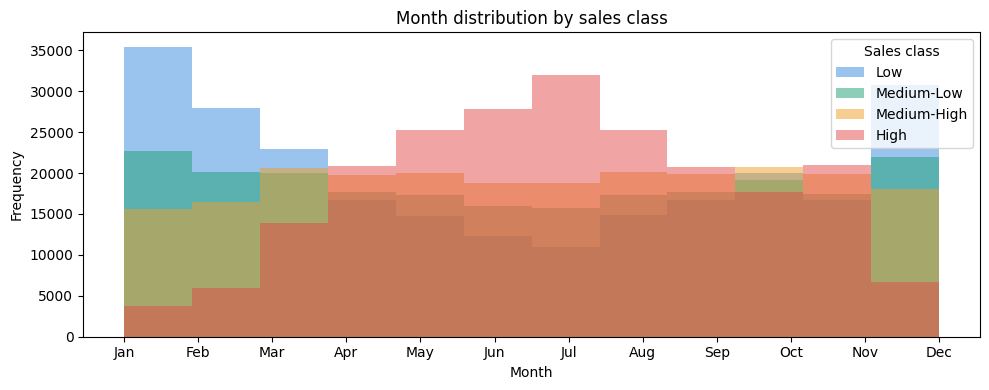

In [35]:
# month distribution by sales class
plt.figure(figsize=(10, 4))
for label, color in zip(classes, colors):
    subset = train_df[train_df['sales_class'] == label]
    plt.hist(subset['month'], bins=12, alpha=0.5, label=label, color=color)
plt.title('Month distribution by sales class')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Sales class')
plt.tight_layout()
plt.show()

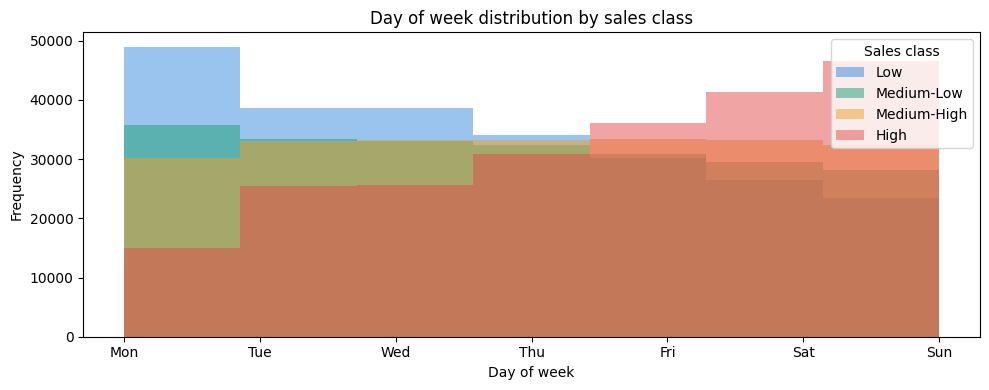

In [36]:
# day of the week distribution by sales class
plt.figure(figsize=(10, 4))
for label, color in zip(classes, colors):
    subset = train_df[train_df['sales_class'] == label]
    plt.hist(subset['day_of_week'], bins=7, alpha=0.5, label=label, color=color)
plt.title('Day of week distribution by sales class')
plt.xlabel('Day of week')
plt.ylabel('Frequency')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.legend(title='Sales class')
plt.tight_layout()
plt.show()

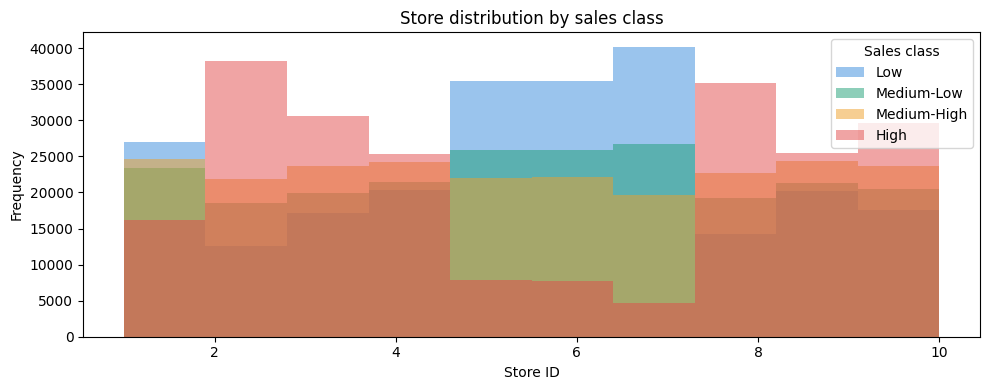

In [37]:
# store distribution by sales class
plt.figure(figsize=(10, 4))
for label, color in zip(classes, colors):
    subset = train_df[train_df['sales_class'] == label]
    plt.hist(subset['store'], bins=10, alpha=0.5, label=label, color=color)
plt.title('Store distribution by sales class')
plt.xlabel('Store ID')
plt.ylabel('Frequency')
plt.legend(title='Sales class')
plt.tight_layout()
plt.show()

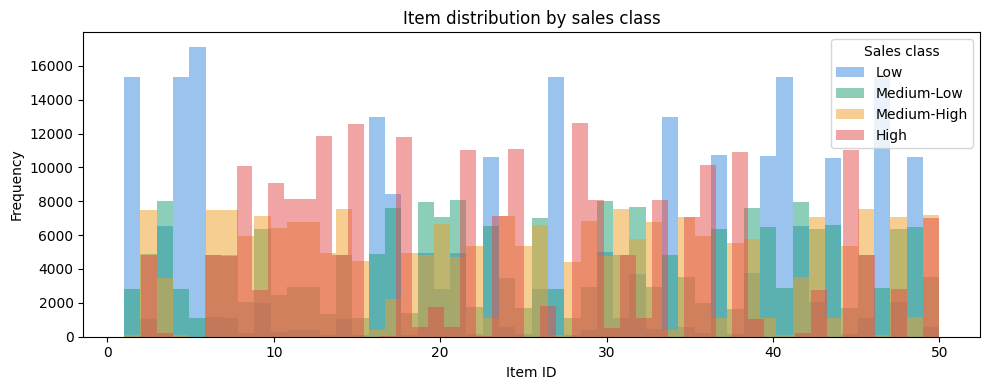

In [38]:
# item distribution by sales class
plt.figure(figsize=(10, 4))
for label, color in zip(classes, colors):
    subset = train_df[train_df['sales_class'] == label]
    plt.hist(subset['item'], bins=50, alpha=0.5, label=label, color=color)
plt.title('Item distribution by sales class')
plt.xlabel('Item ID')
plt.ylabel('Frequency')
plt.legend(title='Sales class')
plt.tight_layout()
plt.show()

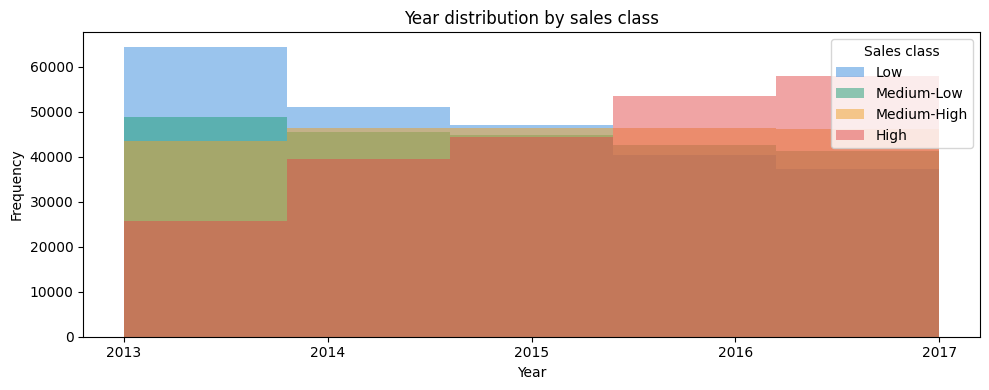

In [39]:
# year distribution by sales class
plt.figure(figsize=(10, 4))
for label, color in zip(classes, colors):
    subset = train_df[train_df['sales_class'] == label]
    plt.hist(subset['year'], bins=5, alpha=0.5, label=label, color=color)
plt.title('Year distribution by sales class')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.xticks([2013, 2014, 2015, 2016, 2017])
plt.legend(title='Sales class')
plt.tight_layout()
plt.show()

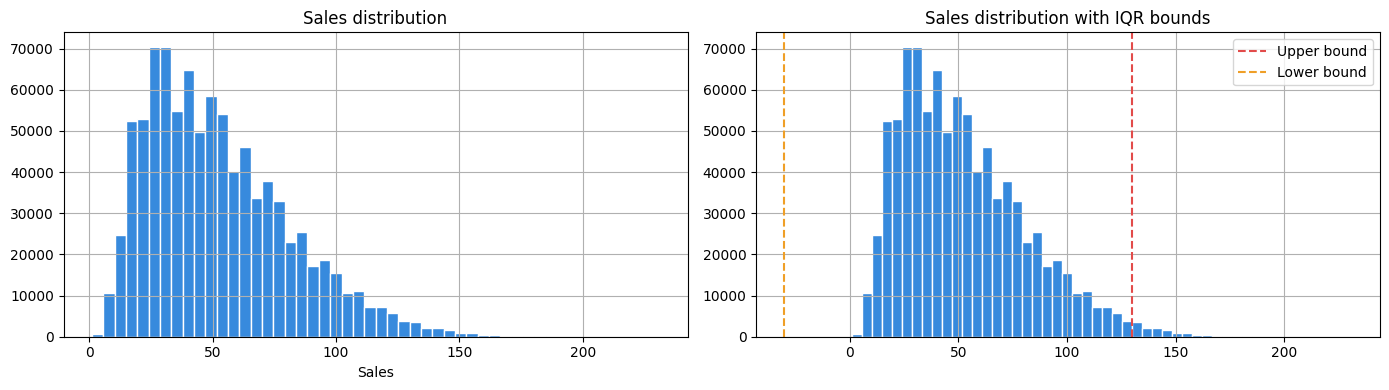

In [40]:
# Sales histogram with IQR bounds
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_df['sales'].hist(bins=50, ax=axes[0], color='#378ADD', edgecolor='white')
axes[0].set_title('Sales distribution')
axes[0].set_xlabel('Sales')
train_df['sales'].hist(bins=50, ax=axes[1], color='#378ADD', edgecolor='white')
axes[1].axvline(Q3 + 1.5*IQR, color='#E24B4A', linestyle='--', label='Upper bound')
axes[1].axvline(Q1 - 1.5*IQR, color='#EF9F27', linestyle='--', label='Lower bound')
axes[1].set_title('Sales distribution with IQR bounds')
axes[1].legend()
plt.tight_layout()
plt.show()

## EDA Findings

**Month:**
Sales spike in the middle of the year (Jun–Aug) and year-end (Nov-Dec), while Low sales dominate in the winter months (Jan-Feb). This suggests that seasonal pattern makes month the most powerful predictor.

**Day of week:**
Certain days consistently show higher average sales than others,
confirming a weekly cycle the model can learn from.

**Year:**
Average sales grow slightly each year from 2016 to 2017, confirming
an upward trend the model needs to account for.

**Item and Store:**
Some items and stores outsell others, but the differences are smaller
than the seasonal and weekly patterns.

**Conclusion**
Month and year show the clearest class separation. Day of week 
adds a useful weekly signal. Store and item contribute less 
individually, but are included so the model can learn interactions 
between them and time features.

## Feature Engineering

Train and test are combined before feature engineering so both 
get identical features. The combined dataframe is sorted by 
store, item, and date before any calculations.

Four date features are extracted from the date column:
- year
- month
- day_of_week (0 = Monday, 6 = Sunday)
- week_of_year

After feature engineering the combined dataframe is split back 
into train and test.

In [41]:
# sales column to test_df
test_df['sales'] = np.nan

# Combine train and test into one dataframe
combined = pd.concat([train_df, test_df], ignore_index=True)
combined['date'] = pd.to_datetime(combined['date'])

# Sort by store, item, date
combined = combined.sort_values(['store', 'item', 'date']).reset_index(drop=True)

# Date features for the model
combined['year'] = combined['date'].dt.year
combined['month'] = combined['date'].dt.month
combined['day_of_week'] = combined['date'].dt.dayofweek
combined['week_of_year'] = combined['date'].dt.isocalendar().week

# train and test split
train_clean = combined[combined['sales'].notna()].copy()
test_clean  = combined[combined['id'].notna()].copy()

print("train_clean shape:", train_clean.shape)
print("test_clean shape:", test_clean.shape)

train_clean shape: (913000, 10)
test_clean shape: (45000, 10)


## Train and validation split

The data is split along the time axis, rows are never shuffled 
randomly. Shuffling would let the model see future data during 
training, making the evaluation score unrealistically good.

- Train: 2013–2016
- Validation: 2017
- Test: January–March 2018

In [53]:
train = train_clean[train_clean['year'] <  2017]
val = train_clean[train_clean['year'] == 2017]

print(f"Train rows: {len(train):,}  |  Years: {sorted(train['year'].astype(int).unique())}")
print(f"Val rows: {len(val):,}    |  Years: {sorted(val['year'].astype(int).unique())}")

Train rows: 730,500  |  Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Val rows: 182,500    |  Years: [np.int64(2017)]


## LightGBM Model

In [54]:
features = ['store', 'item', 'year', 'month', 'day_of_week']

X_train = train[features]
y_train = train['sales']
X_val = val[features]
y_val = val['sales']

print(f"\nX_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")


X_train: (730500, 5)
X_val: (182500, 5)


In [55]:
lgb_model = lgb.LGBMRegressor(n_estimators=200,learning_rate=0.1,random_state=42)

lgb_model.fit(X_train, y_train)

val_preds = lgb_model.predict(X_val)

def smape(actual, predicted):
    return 100 * np.mean(
        np.abs(actual - predicted) /
        ((np.abs(actual) + np.abs(predicted)) / 2)
    )

score = smape(y_val, val_preds)
print(f"SMAPE Score: {score:.2f}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002948 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 87
[LightGBM] [Info] Number of data points in the train set: 730500, number of used features: 5
[LightGBM] [Info] Start training from score 50.610245
SMAPE Score: 12.78%


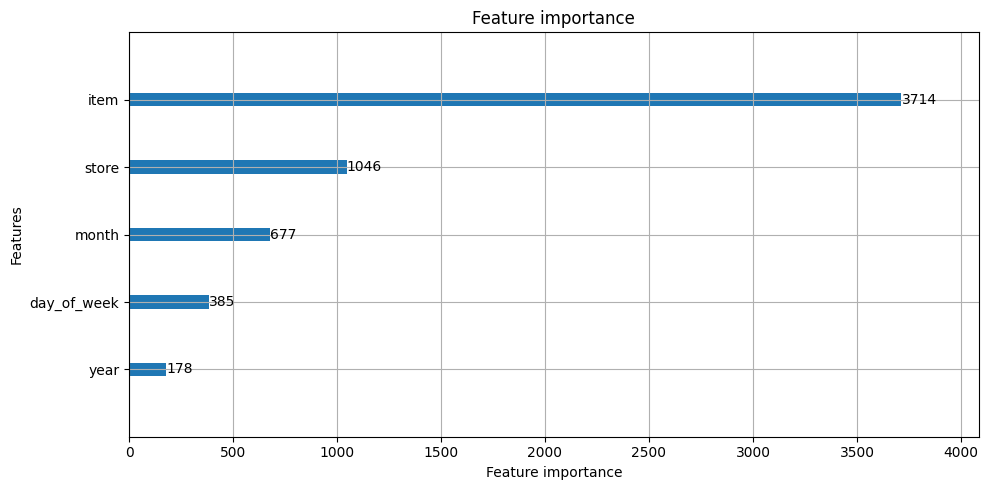

In [56]:
lgb.plot_importance(lgb_model, max_num_features=10, figsize=(10, 5))
plt.title('Feature importance')
plt.tight_layout()
plt.show()

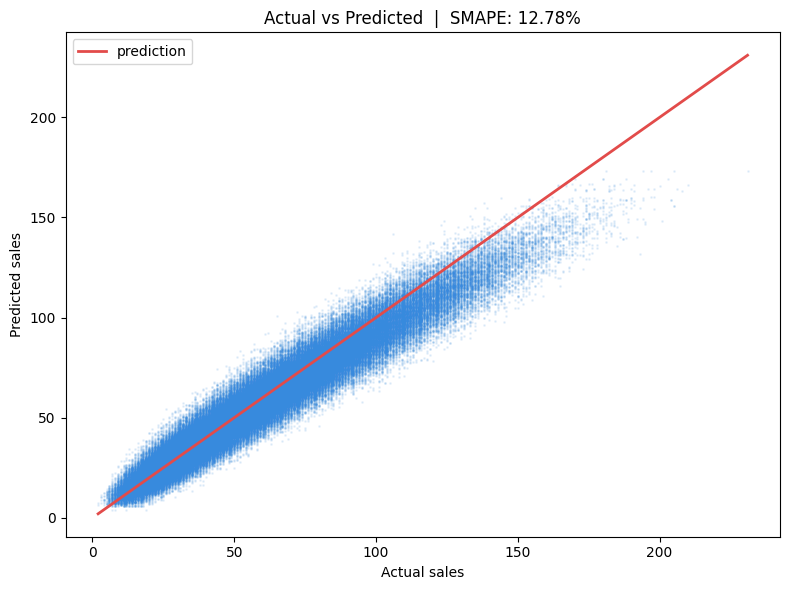

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, val_preds, alpha=0.1, color='#378ADD', s=1)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='#E24B4A', linewidth=2, label='prediction')
plt.xlabel('Actual sales')
plt.ylabel('Predicted sales')
plt.title(f'Actual vs Predicted  |  SMAPE: {score:.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

## Linear Regression Model

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [51]:
X_train_lr = pd.get_dummies(train[features], columns=['store', 'item'])
X_val_lr   = pd.get_dummies(val[features], columns=['store', 'item'])

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)
lr_preds = lr_model.predict(X_val_lr)
lr_score = smape(y_val, lr_preds)

print(f"SMAPE Score: {lr_score:.2f}%")

SMAPE Score: 22.53%


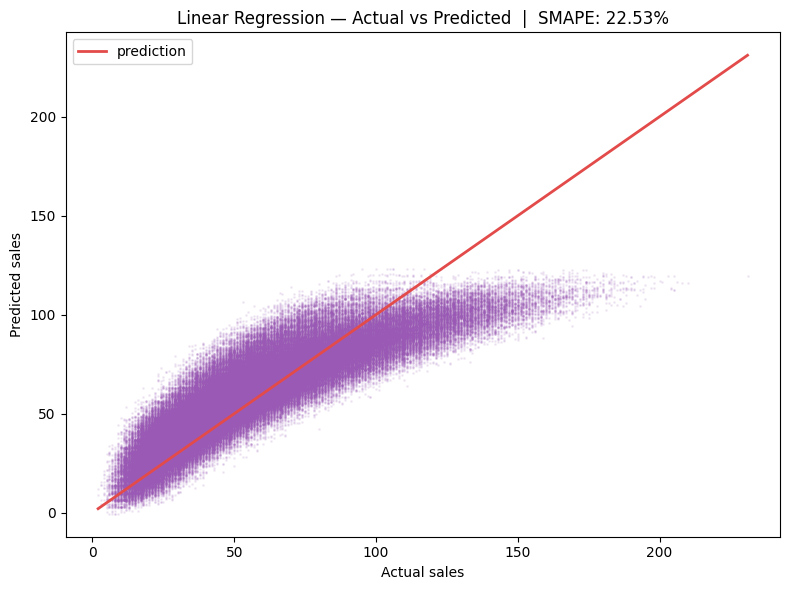

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, lr_preds, alpha=0.1, color='#9B59B6', s=1)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='#E24B4A', linewidth=2, label='prediction')
plt.xlabel('Actual sales')
plt.ylabel('Predicted sales')
plt.title(f'Linear Regression — Actual vs Predicted  |  SMAPE: {lr_score:.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

## Performance comparison

| Model | SMAPE |
|---|---|
| Linear Regression | 22.53% |
| LightGBM | 12.78% |

LightGBM scored 12.78% vs Linear Regression's 22.53%. Even with 
one-hot encoding, Linear Regression cannot learn non-linear patterns 
like high sales on summer weekends. LightGBM's trees learn these 
patterns directly.